In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_parquet(r"C:\Users\Hp\Desktop\strategies\data\static\static_data.parquet")

In [5]:
df.columns

Index(['symbol', 'shortName', 'longName', 'industry', 'sector', 'marketCap',
       'country', 'website', 'longBusinessSummary', 'fullTimeEmployees',
       'fiftyTwoWeekHigh', 'fiftyTwoWeekLow', 'fiftyDayAverage',
       'twoHundredDayAverage', 'trailingPE', 'forwardPE', 'trailingEps',
       'forwardEps', 'bookValue', 'priceToBook', 'dividendRate',
       'dividendYield', 'payoutRatio', 'beta', 'sharesOutstanding',
       'floatShares', 'heldPercentInsiders', 'heldPercentInstitutions',
       'lastSplitFactor', 'lastSplitDate', 'earningsQuarterlyGrowth',
       'revenueGrowth', 'financialCurrency', 'exDividendDate',
       'lastFiscalYearEnd', 'firstTradeDateMilliseconds'],
      dtype='object')

In [6]:
df_csv=df[['symbol', 'shortName', 'longName', 'industry', 'sector', 'marketCap',
       'country', 'website', 'longBusinessSummary', 'fullTimeEmployees', 'sharesOutstanding',
       'floatShares', 'heldPercentInsiders', 'heldPercentInstitutions', 'earningsQuarterlyGrowth',
       'revenueGrowth']]

In [7]:
df_csv

,symbol,shortName,longName,industry,sector,marketCap,country,website,longBusinessSummary,fullTimeEmployees,sharesOutstanding,floatShares,heldPercentInsiders,heldPercentInstitutions,earningsQuarterlyGrowth,revenueGrowth
0,GREENPANEL.NS,GREENPANEL INDUSTRIES LTD,Greenpanel Industries Limited,Lumber & Wood Production,Basic Materials,2.381284e+10,India,https://www.greenpanel.com,Greenpanel Industries Limited engages in the m...,1698.0,1.226274e+08,57773023.0,0.53165,0.30352,0.204,0.158
1,SUMEETINDS.NS,SUMEET IND LIMITED,Sumeet Industries Limited,Textile Manufacturing,Consumer Cyclical,1.546871e+10,India,https://www.sumeetindustries.com,Sumeet Industries Limited manufactures and sel...,621.0,5.263257e+08,1859005.0,0.91790,0.00000,-0.907,0.060
2,ARIHANTSUP.NS,ARIHANT SUPERSTRUCT LTD,Arihant Superstructures Limited,Real Estate - Development,Real Estate,9.166647e+09,India,https://www.asl.net.in,Arihant Superstructures Limited operates as a ...,166.0,4.324999e+07,14575400.0,0.78580,0.00000,-0.605,-0.164
3,TEXINFRA.NS,TEXMACO INFRA & HOLDG LTD,Texmaco Infrastructure & Holdings Limited,Real Estate Services,Real Estate,1.136023e+10,India,https://www.texinfra.in,Texmaco Infrastructure & Holdings Limited enga...,28.0,1.274266e+08,32709433.0,0.68586,0.01300,NaN,-0.039
4,ZYDUSLIFE.NS,ZYDUS LIFESCIENCES LTD,Zydus Lifesciences Limited,Drug Manufacturers - Specialty & Generic,Healthcare,8.963454e+11,India,https://zyduslife.com,Zydus Lifesciences Limited engages in the rese...,27917.0,1.006234e+09,249470290.0,0.75170,0.14890,0.018,0.303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,SUDARSCHEM.NS,SUDARSHAN CHEMICAL INDS L,Sudarshan Chemical Industries Limited,Specialty Chemicals,Basic Materials,6.387613e+10,India,https://www.sudarshan.com,"Sudarshan Chemical Industries Limited, togethe...",1350.0,7.861194e+07,48022842.0,0.40442,0.27552,NaN,2.156
2116,URAVIDEF.NS,URAVI DEFENCE &TECH LTD,Uravi Defence and Technology Limited,Auto Parts,Consumer Cyclical,1.451514e+09,India,https://www.uravilamps.com,Uravi Defence and Technology Limited manufactu...,90.0,1.140000e+07,3346295.0,0.73322,0.02084,0.212,0.018
2117,ENDURANCE.NS,ENDURANCE TECHNO. LTD.,Endurance Technologies Limited,Auto Parts,Consumer Cyclical,3.207535e+11,India,https://www.endurancegroup.com,"Endurance Technologies Limited, together with ...",4370.0,1.406628e+08,25643298.0,0.75001,0.20556,0.202,0.262
2118,NOCIL.NS,NOCIL LIMITED,NOCIL Limited,Specialty Chemicals,Basic Materials,2.404491e+10,India,https://www.nocil.com,NOCIL Limited engages in the manufacture and s...,737.0,1.670249e+08,90986364.0,0.42098,0.08292,-0.283,-0.007


In [8]:
df_csv.to_csv(r"C:\Users\Hp\Desktop\strategies\data\static\static_data.csv", index=False)

In [34]:
import pandas as pd
import numpy as np
import fitz
from sentence_transformers import SentenceTransformer
import faiss

/Users/shrinivasdachawar/Downloads/My_docccc/zzti/strategies/rag_envsource/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_me=pd.read_csv(r"C:\Users\Hp\Desktop\strategies\model\nsei_regime_features.csv")

In [5]:
df_me

,Date,Close,High,Low,Open,Volume,dist_ema_10,dist_ema_21,dist_ema_50,dist_ema_200,...,dist_ema_200_roc_1d,dist_ema_200_roc_5d,rsi_14_roc_1d,rsi_14_roc_5d,adx_14_roc_1d,adx_14_roc_5d,natr_14_roc_1d,natr_14_roc_5d,gk_vol_21_roc_1d,gk_vol_21_roc_5d
0,2021-02-08,15115.799805,15159.900391,15041.049805,15064.299805,671200,0.032654,0.044812,0.057632,0.071452,...,0.012817,0.056322,3.214089,15.860831,0.0,0.0,-0.022584,-0.036873,0.000020,0.000493
1,2021-02-09,15109.299805,15257.099609,15064.299805,15164.150391,713300,0.026200,0.040168,0.054812,0.070235,...,-0.001217,0.029469,-0.225818,7.851845,0.0,0.0,-0.021602,-0.124390,0.000090,0.000335
2,2021-02-10,15106.500000,15168.250000,14977.200195,15119.049805,624800,0.021181,0.036209,0.052363,0.069291,...,-0.000943,0.018961,-0.104242,5.199918,0.0,0.0,-0.021235,-0.152148,0.000111,0.000201
3,2021-02-11,15173.299805,15188.500000,15065.400391,15073.250000,500100,0.020926,0.036946,0.054658,0.073229,...,0.003938,0.016001,1.230468,4.611745,0.0,0.0,-0.058687,-0.173867,-0.000064,0.000067
4,2021-02-12,15163.299805,15243.500000,15081.000000,15186.200195,571800,0.016510,0.032858,0.051737,0.071748,...,-0.001481,0.013114,-0.419713,3.694784,0.0,0.0,-0.028673,-0.152780,-0.000104,0.000052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1316,2026-06-10,23214.949219,23425.349609,23184.599609,23233.949219,380000,-0.007293,-0.013942,-0.024637,-0.052585,...,-0.000607,-0.005325,-0.568582,-2.390205,0.0,0.0,-0.014914,-0.100340,0.000112,0.000003
1317,2026-06-11,23161.599609,23327.449219,23072.050781,23104.400391,363000,-0.007848,-0.014756,-0.025851,-0.054247,...,-0.001662,-0.007877,-1.150911,-3.858778,0.0,0.0,-0.007861,-0.077647,-0.000034,-0.000020
1318,2026-06-12,23622.900391,23645.349609,23313.900391,23412.550781,351900,0.009726,0.004422,-0.006198,-0.035070,...,0.019176,0.012871,13.393826,10.614883,0.0,0.0,0.035009,-0.022409,-0.000075,0.000075
1319,2026-06-15,23853.900391,24011.400391,23817.800781,23984.849609,398900,0.015979,0.012932,0.003381,-0.025386,...,0.009684,0.031942,5.076206,20.564610,0.0,0.0,0.013610,-0.020287,-0.000237,-0.000179


In [2]:
df_result=pd.read_csv(r"C:\Users\Hp\Desktop\strategies\model\nsei_regime_results.csv")

In [3]:
df_result

,Date,Close,gmm_cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2,gmm_regime,numeric_regime,smoothed_numeric_regime,smoothed_regime
0,2021-02-08,15115.799805,0,0.999760,0.000240,2.158542e-11,Neutral,1,1,Neutral
1,2021-02-09,15109.299805,0,0.977668,0.022332,5.571384e-12,Neutral,1,1,Neutral
2,2021-02-10,15106.500000,0,0.977188,0.022812,1.717211e-11,Neutral,1,1,Neutral
3,2021-02-11,15173.299805,0,0.988363,0.011637,3.702115e-11,Neutral,1,1,Neutral
4,2021-02-12,15163.299805,0,0.972285,0.027715,3.330314e-10,Neutral,1,1,Neutral
...,...,...,...,...,...,...,...,...,...,...
1316,2026-06-10,23214.949219,1,0.274151,0.725849,1.201805e-07,Risk-Off,0,0,Risk-Off
1317,2026-06-11,23161.599609,1,0.221430,0.778570,1.568849e-07,Risk-Off,0,0,Risk-Off
1318,2026-06-12,23622.900391,0,0.999112,0.000888,2.360438e-08,Neutral,1,1,Neutral
1319,2026-06-15,23853.900391,0,0.998597,0.001403,7.805292e-10,Neutral,1,1,Neutral


In [4]:
df_tru=pd.read_csv(r"C:\Users\Hp\Desktop\strategies\model\ground_truth.csv")

In [5]:
df_tru

,date,gt_regime
0,2025-01-01,RISK_OFF
1,2025-01-02,RISK_OFF
2,2025-01-03,RISK_OFF
3,2025-01-06,RISK_OFF
4,2025-01-07,RISK_OFF
...,...,...
343,2026-05-22,NEUTRAL
344,2026-05-25,NEUTRAL
345,2026-05-26,NEUTRAL
346,2026-05-27,NEUTRAL


In [8]:
df_left= pd.merge(df_result,df_tru, how='left',left_on="Date", right_on=['date'])

In [10]:
df_left=df_left[df_left['gt_regime'].notna()]

In [12]:
df_left['gt_regime'].value_counts()

gt_regime
RISK_OFF    125
RISK_ON     118
NEUTRAL     104
Name: count, dtype: int64

In [13]:
# Complete the assignment using .map() to assign string labels
df_left["updated_regime"] = df_left["smoothed_numeric_regime"].map(
    {0: "RISK_OFF", 1: "NEUTRAL", 2: "RISK_ON"}
)

C:\Users\Hp\AppData\Local\Temp\ipykernel_22208\3657336161.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_left["updated_regime"] = df_left["smoothed_numeric_regime"].map(


In [14]:
df_left

,Date,Close,gmm_cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2,gmm_regime,numeric_regime,smoothed_numeric_regime,smoothed_regime,date,gt_regime,updated_regime
962,2025-01-01,23742.900391,1,0.260727,0.736436,2.836575e-03,Risk-Off,0,0,Risk-Off,2025-01-01,RISK_OFF,RISK_OFF
963,2025-01-02,24188.650391,0,0.999980,0.000001,1.878632e-05,Neutral,1,1,Neutral,2025-01-02,RISK_OFF,NEUTRAL
964,2025-01-03,24004.750000,1,0.258991,0.740954,5.490375e-05,Risk-Off,0,0,Risk-Off,2025-01-03,RISK_OFF,RISK_OFF
965,2025-01-06,23616.050781,1,0.019008,0.980992,1.379279e-07,Risk-Off,0,0,Risk-Off,2025-01-06,RISK_OFF,RISK_OFF
966,2025-01-07,23707.900391,0,0.760992,0.238871,1.362689e-04,Neutral,1,1,Neutral,2025-01-07,RISK_OFF,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,2026-05-22,23719.300781,1,0.349356,0.650644,4.988453e-08,Risk-Off,0,0,Risk-Off,2026-05-22,NEUTRAL,RISK_OFF
1305,2026-05-25,24031.699219,0,0.967321,0.032679,7.414640e-09,Neutral,1,1,Neutral,2026-05-25,NEUTRAL,NEUTRAL
1306,2026-05-26,23913.699219,0,0.718462,0.281538,7.868500e-11,Neutral,1,1,Neutral,2026-05-26,NEUTRAL,NEUTRAL
1307,2026-05-27,23907.150391,0,0.977830,0.022170,3.904677e-10,Neutral,1,1,Neutral,2026-05-27,NEUTRAL,NEUTRAL


In [15]:
from sklearn.metrics import confusion_matrix

# 1. Define the explicit order of your 3x3 matrix labels
labels = ["RISK_OFF", "NEUTRAL", "RISK_ON"]

# 2. Compute the 3x3 confusion matrix
cm = confusion_matrix(df_left["gt_regime"], df_left["updated_regime"], labels=labels)


In [16]:
cm

array([[67, 56,  2],
       [10, 25, 69],
       [ 8, 34, 76]])

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

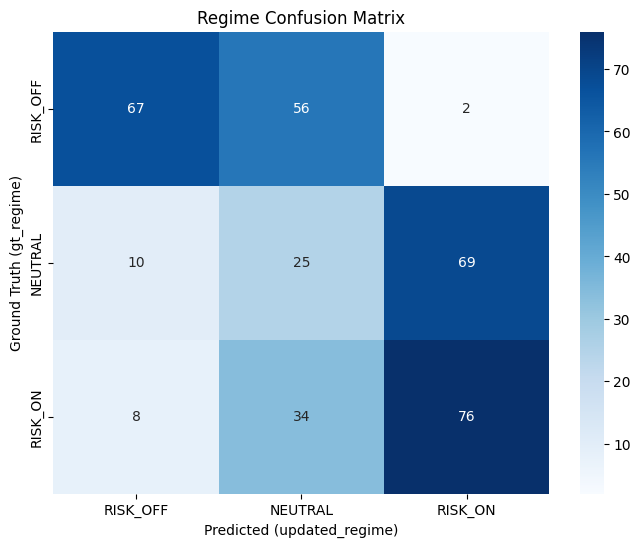

In [19]:

# 3. Plot the matrix using Seaborn for a clean visual overview
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.title("Regime Confusion Matrix")
# True labels are on the vertical axis, predictions on horizontal
plt.ylabel("Ground Truth (gt_regime)")
plt.xlabel("Predicted (updated_regime)")
plt.show()

Fetching data for MTARTECH.NS from 2025-04-29 to 2026-06-18...


[*********************100%***********************]  1 of 1 completed


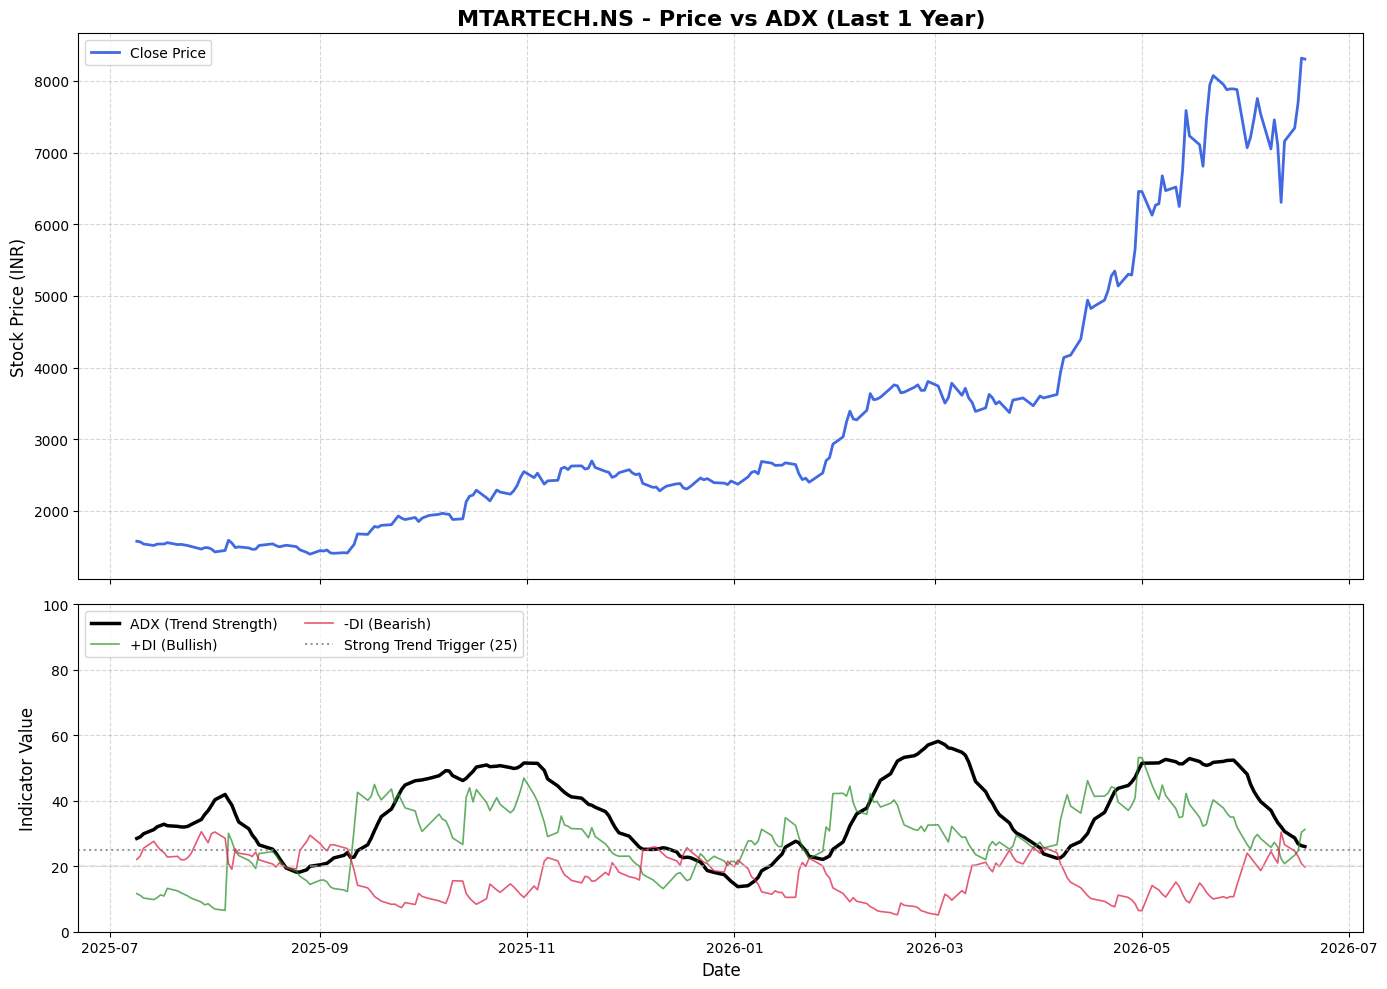

In [ ]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import yfinance as yf

# ==============================================================================
# 1. FETCH THE DATA
# ==============================================================================
# Define the ticker symbol for MTAR Tech on the National Stock Exchange (NSE)
ticker = "MTARTECH.NS"

# Set the timeframe for the last 1 year (plus padding to handle indicator warmup)
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=365 + 50)  # 50 extra days for indicator smoothing

print(f"Fetching data for {ticker} from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}...")
df = yf.download(ticker, start=start_date, end=end_date)

# Handle multi-level columns if returned by newer yfinance versions
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# ==============================================================================
# 2. CALCULATE ADX (14-PERIOD)
# ==============================================================================
period = 14

# Calculate Directional Movement (+DM and -DM)
df["High_Chg"] = df["High"].diff()
df["Low_Chg"] = df["Low"].shift(1) - df["Low"]

df["+DM"] = np.where(
    (df["High_Chg"] > df["Low_Chg"]) & (df["High_Chg"] > 0), df["High_Chg"], 0
)
df["-DM"] = np.where(
    (df["Low_Chg"] > df["High_Chg"]) & (df["Low_Chg"] > 0), df["Low_Chg"], 0
)

# Calculate True Range (TR)
df["TR1"] = df["High"] - df["Low"]
df["TR2"] = (df["High"] - df["Close"].shift(1)).abs()
df["TR3"] = (df["Low"] - df["Close"].shift(1)).abs()
df["TR"] = df[["TR1", "TR2", "TR3"]].max(axis=1)

# Smooth TR, +DM, and -DM using Wilder's Smoothing Technique
df["TR_smoothed"] = df["TR"].rolling(window=period).sum()
df["+DM_smoothed"] = df["+DM"].rolling(window=period).sum()
df["-DM_smoothed"] = df["-DM"].rolling(window=period).sum()

for i in range(period, len(df)):
    df.iloc[i, df.columns.get_loc("TR_smoothed")] = (
        df.iloc[i - 1, df.columns.get_loc("TR_smoothed")]
        - (df.iloc[i - 1, df.columns.get_loc("TR_smoothed")] / period)
        + df.iloc[i, df.columns.get_loc("TR")]
    )
    df.iloc[i, df.columns.get_loc("+DM_smoothed")] = (
        df.iloc[i - 1, df.columns.get_loc("+DM_smoothed")]
        - (df.iloc[i - 1, df.columns.get_loc("+DM_smoothed")] / period)
        + df.iloc[i, df.columns.get_loc("+DM")]
    )
    df.iloc[i, df.columns.get_loc("-DM_smoothed")] = (
        df.iloc[i - 1, df.columns.get_loc("-DM_smoothed")]
        - (df.iloc[i - 1, df.columns.get_loc("-DM_smoothed")] / period)
        + df.iloc[i, df.columns.get_loc("-DM")]
    )

# Calculate Directional Indicators (+DI and -DI)
df["+DI"] = 100 * (df["+DM_smoothed"] / df["TR_smoothed"])
df["-DI"] = 100 * (df["-DM_smoothed"] / df["TR_smoothed"])

# Calculate Directional Movement Index (DX)
df["DX"] = 100 * ((df["+DI"] - df["-DI"]).abs() / (df["+DI"] + df["-DI"]))

# Calculate Average Directional Index (ADX) using Wilder's smoothing method
df["ADX"] = df["DX"].rolling(window=period).mean()
for i in range(2 * period - 1, len(df)):
    df.iloc[i, df.columns.get_loc("ADX")] = (
        df.iloc[i - 1, df.columns.get_loc("ADX")] * (period - 1)
        + df.iloc[i, df.columns.get_loc("DX")]
    ) / period

# Trim out the initial warmup rows so we show exactly the last 1 year of data
df_clean = df.iloc[50:].copy()

# ==============================================================================
# 3. PLOT THE DATA
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [2, 1.2]}
)

# Top Plot: Stock Price Trend
ax1.plot(df_clean.index, df_clean["Close"], label="Close Price", color="royalblue", lw=2)
ax1.set_title(f"{ticker} - Price vs ADX (Last 1 Year)", fontsize=16, fontweight="bold")
ax1.set_ylabel("Stock Price (INR)", fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

# Bottom Plot: ADX & DI Lines
ax2.plot(df_clean.index, df_clean["ADX"], label="ADX (Trend Strength)", color="black", lw=2.5)
ax2.plot(df_clean.index, df_clean["+DI"], label="+DI (Bullish)", color="forestgreen", lw=1.2, alpha=0.7)
ax2.plot(df_clean.index, df_clean["-DI"], label="-DI (Bearish)", color="crimson", lw=1.2, alpha=0.7)

# Visual Anchors for ADX Thresholds
ax2.axhline(25, color="gray", linestyle=":", alpha=0.8, label="Strong Trend Trigger (25)")
ax2.axhline(20, color="lightgray", linestyle="--", alpha=0.5)

ax2.set_ylabel("Indicator Value", fontsize=12)
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylim(0, 100)  # ADX scale is bound from 0 to 100
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left", ncol=2)

plt.tight_layout()
plt.show()


In [18]:
df_ann=pd.read_parquet("/Users/shrinivasdachawar/Downloads/My_docccc/zzti/strategies/data/Announcements/announcements.parquet")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/shrinivasdachawar/Downloads/My_docccc/zzti/strategies/data/Announcements/announcements.parquet'

In [73]:
df_ann1=df_ann[df_ann['date']>'2026-04-01 18:40:24']

In [69]:
df_ann1.tail()

,symbol,seq_id,subject,company_name,attachment_text,industry,has_xbrl,date_raw,announcement_datetime,sort_datetime,attachment_url,date,index_name,classification
171104,BANKINDIA,106615073,record date,Bank of India,Bank Of India has informed the Exchange that R...,Banks,True,08052026183346,08-May-2026 18:33:46,2026-05-08 18:33:46,https://nsearchives.nseindia.com/corporate/BAN...,2026-05-08 18:33:46,equities,Bonus/Issue
171105,GRINDWELL,106615075,record date,Grindwell Norton Limited,Grindwell Norton Limited has informed the Exch...,Abrasives,True,08052026183412,08-May-2026 18:34:12,2026-05-08 18:34:12,https://nsearchives.nseindia.com/corporate/GRI...,2026-05-08 18:34:12,equities,Bonus/Issue
171106,SWIGGY,106615077,monitoring agency report,Swiggy Limited,Monitoring Agency Report for the quarter ended...,None,True,08052026183442,08-May-2026 18:34:42,2026-05-08 18:34:42,https://nsearchives.nseindia.com/corporate/SWI...,2026-05-08 18:34:42,equities,Other
171107,ALKEM,106615085,press release,Alkem Laboratories Limited,Alkem Laboratories Limited has informed the Ex...,None,True,08052026183838,08-May-2026 18:38:38,2026-05-08 18:38:38,https://nsearchives.nseindia.com/corporate/ALK...,2026-05-08 18:38:38,equities,updates
171108,HYUNDAI,106615087,general updates,Hyundai Motor India Limited,Hyundai Motor India Limited has informed the E...,None,True,08052026184002,08-May-2026 18:40:02,2026-05-08 18:40:02,https://nsearchives.nseindia.com/corporate/HMI...,2026-05-08 18:40:02,equities,updates


In [70]:
df_ann1['classification'].value_counts()

classification
Other                9461
updates              6608
Investor             1849
Board Meeting        1059
Bonus/Issue           763
Credit Rating         298
orders                205
Merger/Demerger        78
Capacity Addition      56
Name: count, dtype: int64

In [62]:
df_tr=pd.DataFrame(df_ann1[(df_ann1['subject']=='analysts/institutional investor meet/con. call updates')]['attachment_text'].value_counts()).reset_index()

In [79]:
df_ann1[df_ann1['symbol']=='AEROFLEX'].sort_values('date', ascending=False)

,symbol,seq_id,subject,company_name,attachment_text,industry,has_xbrl,date_raw,announcement_datetime,sort_datetime,attachment_url,date,index_name,classification
170087,AEROFLEX,106612748,copy of newspaper publication,Aeroflex Industries Limited,Newspaper advertisement of extract of Audited ...,None,True,07052026150814,07-May-2026 15:08:14,2026-05-07 15:08:14,https://nsearchives.nseindia.com/corporate/AER...,2026-05-07 15:08:14,equities,Other
169615,AEROFLEX,106611586,analysts/institutional investor meet/con. call...,Aeroflex Industries Limited,Audio Recording of the Investors' Conference C...,None,True,06052026182803,06-May-2026 18:28:03,2026-05-06 18:28:03,https://nsearchives.nseindia.com/corporate/AER...,2026-05-06 18:28:03,equities,Investor
169121,AEROFLEX,106610225,statement of deviation(s) or variation(s) unde...,Aeroflex Industries Limited,Aeroflex Industries Limited has informed the E...,None,True,05052026204223,05-May-2026 20:42:23,2026-05-05 20:42:23,https://nsearchives.nseindia.com/corporate/AER...,2026-05-05 20:42:23,equities,Other
169093,AEROFLEX,106610172,updates,Aeroflex Industries Limited,Aeroflex Industries Limited has informed the E...,None,True,05052026195547,05-May-2026 19:55:47,2026-05-05 19:55:47,https://nsearchives.nseindia.com/corporate/AER...,2026-05-05 19:55:47,equities,updates
169063,AEROFLEX,106610116,outcome of board meeting,Aeroflex Industries Limited,Audited Financial Results (Standalone and Cons...,None,True,05052026192138,05-May-2026 19:21:38,2026-05-05 19:21:38,https://nsearchives.nseindia.com/corporate/AER...,2026-05-05 19:21:38,equities,Board Meeting
165276,AEROFLEX,106601425,analysts/institutional investor meet/con. call...,Aeroflex Industries Limited,Aeroflex Industries Limited has informed the E...,None,True,27042026182840,27-Apr-2026 18:28:40,2026-04-27 18:28:40,https://nsearchives.nseindia.com/corporate/AER...,2026-04-27 18:28:40,equities,Investor
163452,AEROFLEX,106596736,analysts/institutional investor meet/con. call...,Aeroflex Industries Limited,Intimation of Schedule of Investors/Analysts M...,None,True,22042026124456,22-Apr-2026 12:44:56,2026-04-22 12:44:56,https://nsearchives.nseindia.com/corporate/AER...,2026-04-22 12:44:56,equities,Investor
162773,AEROFLEX,106594337,updates,Aeroflex Industries Limited,Intimation of Participation in International E...,None,True,20042026171046,20-Apr-2026 17:10:46,2026-04-20 17:10:46,https://nsearchives.nseindia.com/corporate/AER...,2026-04-20 17:10:46,equities,updates
156999,AEROFLEX,NaN,action(s) initiated or orders passed,Aeroflex Industries Limited,nan,nan,False,08042026165840,08-Apr-2026 16:58:40,2026-04-08 16:58:40,https://nsearchives.nseindia.com/corporate/AER...,2026-04-08 16:58:40,equities,Other
157000,AEROFLEX,106583742,action(s) initiated or orders passed,Aeroflex Industries Limited,The intimation under Regulation 30 of the SEBI...,None,True,08042026165840,08-Apr-2026 16:58:40,2026-04-08 16:58:40,https://nsearchives.nseindia.com/corporate/AER...,2026-04-08 16:58:40,equities,Other


In [77]:
df_ann1[df_ann1['attachment_text'].str.contains('audio', na=False)].sort_values('date', ascending=False)

,symbol,seq_id,subject,company_name,attachment_text,industry,has_xbrl,date_raw,announcement_datetime,sort_datetime,attachment_url,date,index_name,classification
170958,CHOLAHLDNG,106614781,analysts/institutional investor meet/con. call...,Cholamandalam Financial Holdings Limited,Cholamandalam Financial Holdings Limited has i...,None,True,08052026165723,08-May-2026 16:57:23,2026-05-08 16:57:23,https://nsearchives.nseindia.com/corporate/CHO...,2026-05-08 16:57:23,equities,Investor
169614,HEROMOTOCO,106611585,analysts/institutional investor meet/con. call...,Hero MotoCorp Limited,Pursuant to Regulation 30 read with Schedule I...,Automobiles - 2 And 3 Wheelers,True,06052026182747,06-May-2026 18:27:47,2026-05-06 18:27:47,https://nsearchives.nseindia.com/corporate/HER...,2026-05-06 18:27:47,equities,Investor
169126,MARICO,106610237,analysts/institutional investor meet/con. call...,Marico Limited,Pursuant to Regulation 30 of the SEBI (Listing...,Personal Care,True,05052026210008,05-May-2026 21:00:08,2026-05-05 21:00:08,https://nsearchives.nseindia.com/corporate/mar...,2026-05-05 21:00:08,equities,Investor
169010,JSL,106610011,analysts/institutional investor meet/con. call...,Jindal Stainless Limited,Jindal Stainless Limited has informed the Exch...,Steel And Steel Products,True,05052026182136,05-May-2026 18:21:36,2026-05-05 18:21:36,https://nsearchives.nseindia.com/corporate/JSL...,2026-05-05 18:21:36,equities,Investor
168389,CDSL,106608648,analysts/institutional investor meet/con. call...,Central Depository Services (India) Limited,CDSL has informed the Exchange about the link ...,None,True,04052026193600,04-May-2026 19:36:00,2026-05-04 19:36:00,https://nsearchives.nseindia.com/corporate/CDS...,2026-05-04 19:36:00,equities,Investor
167461,RRKABEL,106606476,analysts/institutional investor meet/con. call...,R R Kabel Limited,R R Kabel Limited has informed the Exchange ab...,None,True,30042026204126,30-Apr-2026 20:41:26,2026-04-30 20:41:26,https://nsearchives.nseindia.com/corporate/RRK...,2026-04-30 20:41:26,equities,Investor
167436,KAJARIACER,106606425,analysts/institutional investor meet/con. call...,Kajaria Ceramics Limited,Pursuant to the provisions of the Regulation 3...,Ceramics And Sanitaryware,True,30042026201254,30-Apr-2026 20:12:54,2026-04-30 20:12:54,https://nsearchives.nseindia.com/corporate/KAJ...,2026-04-30 20:12:54,equities,Investor
167378,BANSALWIRE,106606333,analysts/institutional investor meet/con. call...,Bansal Wire Industries Limited,Bansal Wire Inudustries Limited has informed t...,None,True,30042026192237,30-Apr-2026 19:22:37,2026-04-30 19:22:37,https://nsearchives.nseindia.com/corporate/BAN...,2026-04-30 19:22:37,equities,Investor
166622,NAVINFLUOR,106604609,analysts/institutional investor meet/con. call...,Navin Fluorine International Limited,Pursuant to Regulation 30 read with Schedule I...,Chemicals - Inorganic,True,29042026203356,29-Apr-2026 20:33:56,2026-04-29 20:33:56,https://nsearchives.nseindia.com/corporate/NAV...,2026-04-29 20:33:56,equities,Investor
166525,EMMVEE,106604436,analysts/institutional investor meet/con. call...,Emmvee Photovoltaic Power Limited,Emmvee Photovoltaic Power Limited has informed...,None,True,29042026183456,29-Apr-2026 18:34:56,2026-04-29 18:34:56,https://nsearchives.nseindia.com/corporate/EMM...,2026-04-29 18:34:56,equities,Investor


In [63]:
print(df_tr.columns)


Index(['attachment_text', 'count'], dtype='str')


In [64]:
results=df_tr[df_tr['attachment_text'].str.lower().str.contains("link", na=False)]

In [65]:
# 1. Filter by subject and "link" in attachment_text
mask = (df_ann1['subject'] == 'analysts/institutional investor meet/con. call updates') & \
       ((df_ann1['attachment_text'].str.lower().str.contains("link", na=False)) | df_ann1['attachment_text'].isnull())

# 2. Apply mask, sort by date (descending), and take top 200
df_tr1 = df_ann1[mask].sort_values(by='date', ascending=False)


In [27]:
df_share=df_ann[df_ann['subject'].str.lower().str.contains("analysts/institutional investor meet/con. call updates")].sort_values('date', ascending=False).head(50)

In [37]:
df_eps=pd.read_csv("/Users/shrinivasdachawar/Downloads/My_docccc/zzti/strategies/data/quarterly/eps_full.csv")

In [42]:
df_eps.head()

,symbol,date,eps
0,20MICRONS,2022-12-31,2.09
1,20MICRONS,2023-03-31,2.64
2,20MICRONS,2023-06-30,4.23
3,20MICRONS,2023-09-30,4.54
4,20MICRONS,2023-12-31,3.25


In [ ]:
df_eps['date'].value_counts()

In [11]:
df_wt= pd.read_parquet("/Users/shrinivasdachawar/Downloads/My_docccc/zzti/strategies/data/static/weightage.parquet")

In [46]:
df_wt[df_wt['index']=='NIFTY 50'].head()

,index,symbol,average,category
200,NIFTY 50,HDFCBANK,10.84,Broad Market
201,NIFTY 50,RELIANCE,8.52,Broad Market
202,NIFTY 50,ICICIBANK,8.35,Broad Market
203,NIFTY 50,BHARTIARTL,5.14,Broad Market
204,NIFTY 50,LT,4.29,Broad Market


In [24]:
left=df_wt.merge(df_tr1, on='symbol', how='left')

In [13]:
list_dt=df_wt['symbol'].unique()

In [ ]:
# SCHNEIDER
# TVSSCS
# # 
from pathlib import Path
import pandas as pd

weightage_path = Path("data/static/weightage.parquet")
daily_dir = Path("data/daily")

w = pd.read_parquet(weightage_path)

weightage_symbols = set(
    w["symbol"].astype(str).str.strip().str.upper()
)

daily_symbols = {
    p.stem.removesuffix(".NS").strip().upper()
    for p in daily_dir.glob("*.parquet")
}

missing = sorted(weightage_symbols - daily_symbols)
extra = sorted(daily_symbols - weightage_symbols)

print(f"Weightage symbols: {len(weightage_symbols)}")
print(f"Daily symbols: {len(daily_symbols)}")
print(f"Missing daily files: {len(missing)}")
print(f"Extra daily files: {len(extra)}")

missing


In [29]:
df_bulk=pd.read_parquet("/Users/shrinivasdachawar/Downloads/My_docccc/zzti/strategies/data/deals_data/bulk_deals.parquet")

In [32]:
df_bulk.head()

,Date,Symbol,Security Name,Client Name,Buy / Sell,Quantity Traded,Trade Price / Wght. Avg. Price,Remarks,Buy/Sell,fetch_date
0,2025-09-29,AAATECH,AAA Technologies Limited,CRAFT EMERGING MARKET FUND PCC- CITADEL CAPITA...,BUY,400000,78.60,-,None,None
1,2025-09-29,AAATECH,AAA Technologies Limited,RUCHI ANJAY AGARWAL,SELL,400000,78.60,-,None,None
2,2025-09-29,AETHER,Aether Industries Limited,AMANSA HOLDINGS PRIVATE LIMITED,BUY,1282613,735.00,-,None,None
3,2025-09-29,AETHER,Aether Industries Limited,GOLDMAN SACHS FDS GOLDMAN SACHS INDIA EQ PORTF...,SELL,1151084,735.01,-,None,None
4,2025-09-29,ANZEN,Anzen Ind Ene Yld Plu Tru,GO DIGIT GENERAL INSURANCE LIMITED,BUY,2175000,115.00,-,None,None


In [9]:
df_orders=pd.read_parquet("/Users/shrinivasdachawar/Downloads/My_docccc/zzti/strategies/data/Announcements/orders_100.parquet")

In [47]:
df_orders.columns

Index(['symbol', 'subject', 'company_name', 'date_raw',
       'announcement_datetime', 'sort_datetime', 'attachment_url', 'date',
       'date_only', 'pdf_text'],
      dtype='str')

In [119]:
import re

def smart_chunk_text(text, chunk_size=400, overlap=100):
    sentences = re.split(r'(?<=[.!?]) +', text)
    
    chunks = []
    current_chunk = ""
    
    for sentence in sentences:
        if len(current_chunk) + len(sentence) < chunk_size:
            current_chunk += " " + sentence
        else:
            chunks.append(current_chunk.strip())
            current_chunk = sentence
    
    if current_chunk:
        chunks.append(current_chunk.strip())
    
    return chunks

In [120]:
all_chunks = []

for _, row in df_orders.iterrows():
    chunks = smart_chunk_text(row["pdf_text"])
    
    for chunk in chunks:
        all_chunks.append({
            "text": chunk,
            "symbol": row["symbol"],
            "date": row["date"],
            "source": "announcement"
        })

In [121]:
chunks_df = pd.DataFrame(all_chunks)

In [122]:
all_chunks

[{'text': '',
  'symbol': 'ADANIPOWER',
  'date': Timestamp('2026-04-02 19:44:15'),
  'source': 'announcement'},
 {'text': 'date: april 2, 2026\nbse limited national stock exchange of india limited\nfloor 25, p j towers, exchange plaza,\ndalal street, bandra kurla complex,\nmumbai – 400 001 bandra (e), mumbai – 400 051\nscrip code: 533096 scrip code: adanipower\ndear sir,\nsub: intimation under regulation 30 of the sebi (listing obligations and disclosures\nrequirements) regulations, 2015 – letter of award\nadani power limited has received a letter of award (“loa”) from maharashtra state\nelectricity distribution co.',
  'symbol': 'ADANIPOWER',
  'date': Timestamp('2026-04-02 19:44:15'),
  'source': 'announcement'},
 {'text': 'limited (“msedcl”) for supply of 2500 mw re rtc power\nfor a period of 25 years from scheduled commencement date of supply, upon apl\nbeing declared as the successful bidder in the e-ra results.\nthe details, as required under sebi (listing obligations and disclo

In [123]:

(chunks_df.tail())

,text,symbol,date,source
774,kodanda rami reddy\ncompany secretary & compli...,LOKESHMACH,2026-03-17 19:25:33,announcement
775,sebi/ho/cfd/cfd-pod-1/p/cir/2023/123 dated: ju...,LOKESHMACH,2026-03-17 19:25:33,announcement
776,whether order(s) / contract(s) have been domes...,LOKESHMACH,2026-03-17 19:25:33,announcement
777,"9,50,01,741/-\nthe order(s)/contract(s); (incl...",LOKESHMACH,2026-03-17 19:25:33,announcement
778,"if yes,\nwhether the same is done at ""arm's le...",LOKESHMACH,2026-03-17 19:25:33,announcement


In [124]:
chunks_df[chunks_df['symbol']=='POWERMECH']

,text,symbol,date,source
94,"date: april 1, 2026\nto to\nlisting department...",POWERMECH,2026-04-01 10:38:37,announcement
95,services\nnational stock exchange of india lim...,POWERMECH,2026-04-01 10:38:37,announcement
96,the details\nof the order as required under th...,POWERMECH,2026-04-01 10:38:37,announcement
97,no particulars details\na name of the entity a...,POWERMECH,2026-04-01 10:38:37,announcement
98,"if no\nyes, whether the same is done at “arm’s...",POWERMECH,2026-04-01 10:38:37,announcement


In [125]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6614.30it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [126]:
texts = chunks_df["text"].tolist()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32
)

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Batches: 100%|██████████| 25/25 [00:05<00:00,  4.89it/s]


In [127]:
print(len(embeddings))
print(embeddings[0].shape)

779
(384,)


In [128]:
import faiss
import numpy as np

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

In [129]:
print(index.ntotal)

779


In [130]:
def retrieve(query, k=5):
    q_emb = model.encode([query])
    
    distances, indices = index.search(q_emb, k)
    
    results = chunks_df.iloc[indices[0]]
    
    return results

In [131]:
output=retrieve("order received by adani power")

In [132]:
output

,text,symbol,date,source
3,"g. highway, khodiyar, www.adanipower.com\nahme...",ADANIPOWER,2026-04-02 19:44:15,announcement
1,"date: april 2, 2026\nbse limited national stoc...",ADANIPOWER,2026-04-02 19:44:15,announcement
2,limited (“msedcl”) for supply of 2500 mw re rt...,ADANIPOWER,2026-04-02 19:44:15,announcement
7,"if yes, whether the\nsame is done at “arm’s le...",ADANIPOWER,2026-04-02 19:44:15,announcement
95,services\nnational stock exchange of india lim...,POWERMECH,2026-04-01 10:38:37,announcement


In [133]:
retrieve("last week order received")

,text,symbol,date,source
622,the orders pertain to the supply of power dist...,MARINE,2026-03-24 10:21:14,announcement
653,the orders pertain to the supply of power dist...,MARINE,2026-03-23 13:42:25,announcement
157,"date: 31/03/2026\nto, to,\nnational stock exch...",INTERARCH,2026-03-31 16:06:47,announcement
511,sebi/ho/cfd/cfd-pod-1/p/cir/2023/123 dated jul...,PACEDIGITK,2026-03-26 12:53:10,announcement
350,"bandra (east), mumbai – 400 051, india.\nscrip...",AVANTEL,2026-03-28 13:04:59,announcement


In [78]:
print(df_orders[df_orders['symbol']=='POWERMECH']['pdf_text'].iloc[0])

date: april 1, 2026
to to
listing department dept. of corp. services
national stock exchange of india limited bse limited
exchange plaza, c-1, block g, phiroze jeejeebhoy towers
bandra kurla complex, dalal street
bandra (e), mumbai – 400 051 mumbai- 400001
symbol/security id: powermech security code: 539302
dear sir/madam,
sub: receipt of order
*****
we are pleased to inform you that the company has secured an order from hindustan zinc limited. the details
of the order as required under the sebi master circular no. sebi/ho/cfd/pod2/cir/p/0155 dated november
11, 2024, are given below:
s. no particulars details
a name of the entity awarding order(s)/ hindustan zinc limited
contract(s) (cin: l27204rj1966plc001208)
b significant terms and conditions of scope of work: the company is responsible for
order(s)/ contracts(s) awarded in brief comprehensive operation and maintenance of the 91.5 mw
cpp and transmission line up to the mrss, acting as an
independent contractor on behalf of hindustan